In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('Training_data_5.csv')

In [2]:
df.head()


,News Headline,News Topic
0,<html> <body> News Headlines:\n <br> <b> New H...,Science and Technology
1,<html> <body> News Headlines:\n <br> <b> Trans...,Sports
2,<html> <body> News Headlines:\n <br> <b> NASA ...,Science and Technology
3,<html> <body> News Headlines:\n <br> <b> Top-s...,Sports
4,<html> <body> News Headlines:\n <br> <b> Shara...,Sports


In [3]:
df['News Topic'].value_counts()

News Topic
World News                44319
Science and Technology    20129
Business                  15075
Sports                    13706
Name: count, dtype: int64

In [4]:
import string
import re
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from bs4 import BeautifulSoup

nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()
def Clean_headlines(text):
  text = BeautifulSoup(text, "html.parser")
  text = text.get_text()
  text = str(text).lower()
  text = re.sub(r'http\S+ | www\S+ | https\S+', '', text)
  text = text.translate(str.maketrans('', '', string.punctuation))
  text = re.sub(r'\d+','', text)
  tokens = word_tokenize(text)
  stop_words = set(stopwords.words('english'))
  tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
  return ' '.join(tokens)


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Suf48\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Suf48\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Suf48\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [5]:
df['clean_news'] = df['News Headline'].apply(Clean_headlines)

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['labels'] = le.fit_transform(df['News Topic'])

In [7]:
df.head()

,News Headline,News Topic,clean_news,labels
0,<html> <body> News Headlines:\n <br> <b> New H...,Science and Technology,news headline new hybrid disc offer cddvd comb...,1
1,<html> <body> News Headlines:\n <br> <b> Trans...,Sports,news headline transaction baseball major leagu...,2
2,<html> <body> News Headlines:\n <br> <b> NASA ...,Science and Technology,news headline nasa administrator applies louis...,1
3,<html> <body> News Headlines:\n <br> <b> Top-s...,Sports,news headline topseed bartoli upset local favo...,2
4,<html> <body> News Headlines:\n <br> <b> Shara...,Sports,news headline sharapova loses wild card conn a...,2


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['clean_news'], df['labels'], test_size=0.2, 
    random_state=42, stratify=df['labels'] 
)

In [9]:
from sklearn.utils import class_weight
import numpy as np


weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)


class_weight_dict = dict(enumerate(weights))

print("Class Weights:", class_weight_dict)

Class Weights: {0: np.float64(1.546082089552239), 1: np.float64(1.1579053592498292), 2: np.float64(1.7004787961696306), 3: np.float64(0.5258990269355521)}


In [10]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokens = Tokenizer(num_words=20000, oov_token='<OOV>')
tokens.fit_on_texts(X_train)   

X_train_seq = tokens.texts_to_sequences(X_train)
X_test_seq  = tokens.texts_to_sequences(X_test)


lengths = [len(s) for s in X_train_seq]
max_len = int(np.percentile(lengths, 95))
print(f"95th percentile length: {max_len}")

95th percentile length: 37


In [11]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=max_len, padding='post')

In [12]:
import tensorflow as tf
seq_len = X_train_pad.shape[1]
pos_indices = tf.range(start=0, limit=seq_len, delta=1)
pos_indices = tf.expand_dims(pos_indices, axis=0)

In [21]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Add, LayerNormalization, MultiHeadAttention, Dropout, Dense, GlobalAveragePooling1D
i = Input(shape=(max_len,))

e = Embedding(input_dim=20000, output_dim=64)(i)
p = Embedding(input_dim=seq_len, output_dim=64)(pos_indices)
x = Add()([e, p])
x = LayerNormalization()(x)

attn_output = MultiHeadAttention(num_heads=2, key_dim=64)(x, x)
x = Add()([x, attn_output])        
x = LayerNormalization()(x)        
x = Dropout(0.2)(x)                
ff = Dense(128, activation='relu')(x)
ff = Dense(64)(ff)
x = Add()([x, ff])                 
x = LayerNormalization()(x)
x = GlobalAveragePooling1D()(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(4, activation='softmax')(x)

model = Model(inputs=i, outputs=outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 37)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 37, 64)    │  1,280,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (1, 37, 64)       │          0 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (1, 37, 64)       │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (1, 37, 64)       │     33,216 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (1, 37, 64)       │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (1, 37, 64)       │        128 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (1, 37, 64)       │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (1, 37, 128)      │      8,320 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (1, 37, 64)       │      8,256 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (1, 37, 64)       │          0 │ dropout_4[0][0],  │
│                     │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (1, 37, 64)       │        128 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (1, 64)           │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (1, 64)           │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (1, 64)           │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (1, 4)            │        260 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,334,596 (5.09 MB)

 Trainable params: 1,334,596 (5.09 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
from tensorflow.keras.optimizers.schedules import CosineDecay
lr_schedule = CosineDecay(initial_learning_rate=1e-3, decay_steps=2331*10)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)


model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [26]:
from tensorflow.keras.callbacks import EarlyStopping

stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [27]:
model.fit(X_train_pad, y_train, epochs=20, validation_data=(X_test_pad, y_test), batch_size=32, callbacks=[stop], class_weight=class_weight_dict)

Epoch 1/20
2331/2331 ━━━━━━━━━━━━━━━━━━━━ 32s 12ms/step - accuracy: 0.8844 - loss: 0.3385 - val_accuracy: 0.8952 - val_loss: 0.3149
Epoch 2/20
2331/2331 ━━━━━━━━━━━━━━━━━━━━ 28s 12ms/step - accuracy: 0.9404 - loss: 0.1753 - val_accuracy: 0.9144 - val_loss: 0.2799
Epoch 3/20
2331/2331 ━━━━━━━━━━━━━━━━━━━━ 28s 12ms/step - accuracy: 0.9600 - loss: 0.1169 - val_accuracy: 0.9221 - val_loss: 0.2883
Epoch 4/20
2331/2331 ━━━━━━━━━━━━━━━━━━━━ 28s 12ms/step - accuracy: 0.9736 - loss: 0.0773 - val_accuracy: 0.9245 - val_loss: 0.3002
Epoch 5/20
2331/2331 ━━━━━━━━━━━━━━━━━━━━ 29s 12ms/step - accuracy: 0.9828 - loss: 0.0474 - val_accuracy: 0.9257 - val_loss: 0.4139


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences


test_phrases = [
    "Charity director kidnapped in Iraq Insurgents abducted the local director of CARE International from her car in Baghdad yesterday, targeting a charity worker who has championed ordinary Iraqis for decades.", 
    "Sofia Breaks Through Cyber Gang Firewall The Bulgarian counterfeit master of Bill Gates-card has played a crucial role in the international cyber gang busted in seven countries earlier this week."
]
#worldnews
#science 

sequences = tokens.texts_to_sequences(test_phrases)
padded = pad_sequences(sequences, maxlen=37, padding='post')


predictions = model.predict(padded)


for i, pred in enumerate(predictions):
    class_idx = np.argmax(pred)
    confidence = pred[class_idx] * 100
    print(f"Text: {test_phrases[i]}")
    print(f"Predicted Class: {class_idx} ({confidence:.2f}% confidence)\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
Text: Charity director kidnapped in Iraq Insurgents abducted the local director of CARE International from her car in Baghdad yesterday, targeting a charity worker who has championed ordinary Iraqis for decades.
Predicted Class: 3 (80.14% confidence)

Text: Sofia Breaks Through Cyber Gang Firewall The Bulgarian counterfeit master of Bill Gates-card has played a crucial role in the international cyber gang busted in seven countries earlier this week.
Predicted Class: 1 (97.45% confidence)



In [29]:
le.classes_

array(['Business', 'Science and Technology', 'Sports', 'World News'],
      dtype=object)

In [30]:
predictions = model.predict(X_test_pad)

583/583 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


  1/583 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step

583/583 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
                        precision    recall  f1-score   support

              Business       0.81      0.87      0.84      3015
Science and Technology       0.88      0.88      0.88      4026
                Sports       0.90      0.98      0.94      2741
            World News       0.98      0.92      0.95      8864

              accuracy                           0.91     18646
             macro avg       0.89      0.91      0.90     18646
          weighted avg       0.92      0.91      0.92     18646

[[2621  303   22   69]
 [ 294 3561   57  114]
 [  32   12 2676   21]
 [ 289  172  211 8192]]


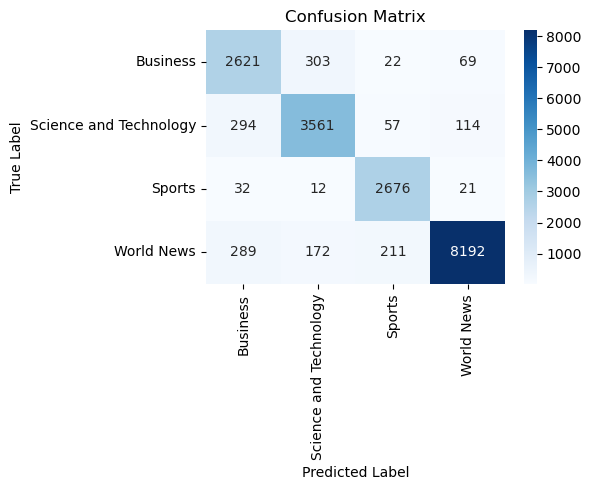

In [31]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test_pad).argmax(axis=1)

print(classification_report(y_test, y_pred, target_names=le.classes_))
print(confusion_matrix(y_test, y_pred))
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
import pickle

model.save('multi_class_transformer.keras')


with open('tokenizer.pkl', 'wb') as handle:
    pickle.dump(tokens, handle)


with open('label_encoder.pkl', 'wb') as handle:
    pickle.dump(le, handle)

In [ ]:
test_examples = [
    "UN Security Council calls for ceasefire in Middle East.",
    "Quantum computing breakthrough doubles processing speed.",
    "Underdog team wins championship in overtime thriller.",
    "Federal Reserve signals potential interest rate cuts."
]


seqs = tokens.texts_to_sequences(test_examples)
padded_test = pad_sequences(seqs, maxlen=37, padding='post')

batch_preds = model.predict(padded_test)
batch_labels = np.argmax(batch_preds, axis=1)


for text, label_idx in zip(test_examples, batch_labels):
    print(f"[{le.classes_[label_idx]}] -> {text}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
[World News] -> UN Security Council calls for ceasefire in Middle East.
[Science and Technology] -> Quantum computing breakthrough doubles processing speed.
[Sports] -> Underdog team wins championship in overtime thriller.
[Business] -> Federal Reserve signals potential interest rate cuts.
